In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-


# Deep Neural Networks

## Session 05z - For animation
### Neural Network with :
- One hidden layer 
- ${Tanh}$ activation function


<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com">

In [2]:
###-----------------
### Import Libraries
###-----------------

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path

from collections.abc import Callable
from typing import Literal

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

%matplotlib inline

In [3]:
###----------------
### Some parameters
###----------------

inpDir = Path('../input')
outDir = Path('../output')
aniDir = 'make_moons'
#aniDir = 'make_circle'
RANDOM_STATE = 24 # REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results

EPOCHS = 6001 # number of epochs
ALPHA = 0.1 # learning rate
NUM_SAMPLES = 1280 # How many samples we want to generate 
NOISE = 0.2 # Noise to be introduced in the data
TEST_SIZE = 0.2
INTERVAL = 10 # interval to create animation images
FACTOR = 0.8
# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (30, 20),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }

CMAP = 'coolwarm' # plt.cm.Spectral

plt.rcParams.update(params)

### Helper Functions

In [4]:
###-----------------------------------
### Function to plot Decision boundary
###-----------------------------------


In [ ]:
def fn_save_decision_boundary(pred_func, X_tr, y_tr, X_ts, y_ts, idx, hist_df=None):
    '''
    Enhanced version with loss curve and weight evolution as picture-in-picture
    '''
    # Create figure with main plot and insets
    fig, ax_main = plt.subplots(1, 1, figsize=(25, 20))
    
    # --- Main Decision Boundary Plot (same as your original) ---
    h = 0.01
    margin = 10 * h

    xMin = min(X_tr[:, 0].min() - margin, X_ts[:, 0].min() - margin)
    xMax = max(X_tr[:, 0].max() + margin, X_ts[:, 0].max() + margin)
    yMin = min(X_tr[:, 1].min() - margin, X_ts[:, 1].min() - margin)
    yMax = max(X_tr[:, 1].max() + margin, X_ts[:, 1].max() + margin)
    
    xx, yy = np.meshgrid(np.arange(xMin, xMax, h), np.arange(yMin, yMax, h))
    Z = pred_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    contour = ax_main.contourf(xx, yy, Z, cmap=CMAP, alpha=0.8)
    ax_main.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr.argmax(axis=1), s=60, edgecolor='k', cmap=plt.cm.coolwarm, label='Train')
    ax_main.scatter(X_ts[:, 0], X_ts[:, 1], c=y_ts.argmax(axis=1), s=300, marker='*', edgecolor='k', cmap=plt.cm.coolwarm, label='Test')
    
    ax_main.set_xlabel('Axis 1')
    ax_main.set_ylabel('Axis 2')
    #ax_main.set_title(f'Decision Boundary - Epoch {hist_df.iloc[idx]["epochs"] if hist_df is not None else idx}')
    ax_main.set_title(f'Decision Boundary')
    ax_main.legend()
    
    # --- Picture-in-Picture Plots ---
    if hist_df is not None and not hist_df.empty:
        current_epoch = hist_df.iloc[idx]["epoch"]
        
        # Create three inset axes
        # Loss curve inset
        ax_loss = inset_axes(ax_main, width="25%", height="25%", loc='upper left')
        # ax_loss.set_facecolor('gray')
        # ax_loss.patch.set_alpha(0.7)  # Semi-transparent white
        
        # W1 weights inset
        ax_w1 = inset_axes(ax_main, width="25%", height="25%", loc='upper right')
        # ax_w1.set_facecolor('gray')
        # ax_w1.patch.set_alpha(0.7)  # Semi-transparent white
        # W2 weights inset  
        ax_w2 = inset_axes(ax_main, width="25%", height="25%", loc='lower left')
        # ax_w2.set_facecolor('gray')
        # ax_w2.patch.set_alpha(0.7)  # Semi-transparent white
        
        # --- Loss Curve ---
        ax_loss.plot(hist_df['epoch'], hist_df['loss'], 'g-', linewidth=3, label='Loss')
        ax_loss.scatter(current_epoch, hist_df.iloc[idx]['loss'], 
                       c='red', marker='>', s=100, zorder=5, label='Current')
        ax_loss.set_xlim(0, EPOCHS)
        ax_loss.set_ylim(0, hist_df['loss'].max() * 1.1)
        ax_loss.set_title('Loss Curve', fontsize=10)
        ax_loss.set_xlabel('Epoch', fontsize=8)
        ax_loss.set_ylabel('Loss', fontsize=8)
        ax_loss.legend(fontsize=7)
        ax_loss.grid(True, alpha=0.3)
        
        # --- W1 Weights (2x4 matrix) ---
        w1_cols = [col for col in hist_df.columns if col.startswith('W1_')]
        colors = plt.cm.Set1(np.linspace(0, 1, len(w1_cols)))
        
        for i, col in enumerate(w1_cols):
            ax_w1.plot(hist_df['epoch'], hist_df[col], 
                      color=colors[i], linewidth=2, label=f'W1[{i//4},{i%4}]')
        
        # Mark current position
        for i, col in enumerate(w1_cols):
            ax_w1.scatter(current_epoch, hist_df.iloc[idx][col], 
                         color=colors[i], s=30, alpha=0.8, zorder=5)
        
        ax_w1.set_xlim(0, EPOCHS)
        # Dynamic y-limits for W1
        w1_min = hist_df[w1_cols].min().min()
        w1_max = hist_df[w1_cols].max().max()
        w1_range = w1_max - w1_min
        ax_w1.set_ylim(w1_min - 0.1*w1_range, w1_max + 0.1*w1_range)
        ax_w1.set_title('W1 Weights (Input→Hidden)', fontsize=20)
        ax_w1.set_xlabel('Epoch', fontsize=8)
        ax_w1.set_ylabel('Weight Value', fontsize=8)
        ax_w1.legend(fontsize=6, ncol=2)
        ax_w1.grid(True, alpha=0.3)
        
        # --- W2 Weights (4x2 matrix) ---
        w2_cols = [col for col in hist_df.columns if col.startswith('W2_')]
        colors_w2 = plt.cm.Set2(np.linspace(0, 1, len(w2_cols)))
        
        for i, col in enumerate(w2_cols):
            ax_w2.plot(hist_df['epoch'], hist_df[col], 
                      color=colors_w2[i], linewidth=2, label=f'W2[{i//2},{i%2}]')
        
        # Mark current position
        for i, col in enumerate(w2_cols):
            ax_w2.scatter(current_epoch, hist_df.iloc[idx][col], 
                         color=colors_w2[i], s=30, alpha=0.8, zorder=5)
        
        ax_w2.set_xlim(0, EPOCHS)
        # Dynamic y-limits for W2
        w2_min = hist_df[w2_cols].min().min()
        w2_max = hist_df[w2_cols].max().max()
        w2_range = w2_max - w2_min
        ax_w2.set_ylim(w2_min - 0.1*w2_range, w2_max + 0.1*w2_range)
        ax_w2.set_title('W2 Weights (Hidden→Output)', fontsize=20)
        ax_w2.set_xlabel('Epoch', fontsize=8)
        ax_w2.set_ylabel('Weight Value', fontsize=8)
        ax_w2.legend(fontsize=6, ncol=2)
        ax_w2.grid(True, alpha=0.3)

    plt.savefig(outDir/ aniDir/ f'img_{idx:003d}.png', bbox_inches='tight', dpi=100)
    
    # Clean up
    fig.clear()
    plt.close(fig)
    plt.tight_layout()

## Generate Data Set
<p style="font-family: Arial; font-size:1.1em;color:blue;">
Use Sklearn's dataset generator <a href="http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html">make_moon</a>.
</p>

In [6]:
X, y = datasets.make_moons(n_samples=NUM_SAMPLES, shuffle=True, noise=NOISE, random_state=RANDOM_STATE)
# X, y = datasets.make_circles(n_samples=NUM_SAMPLES, shuffle=True, noise=NOISE, random_state=RANDOM_STATE, factor=FACTOR)

In [7]:
X.shape, y.shape

((1280, 2), (1280,))

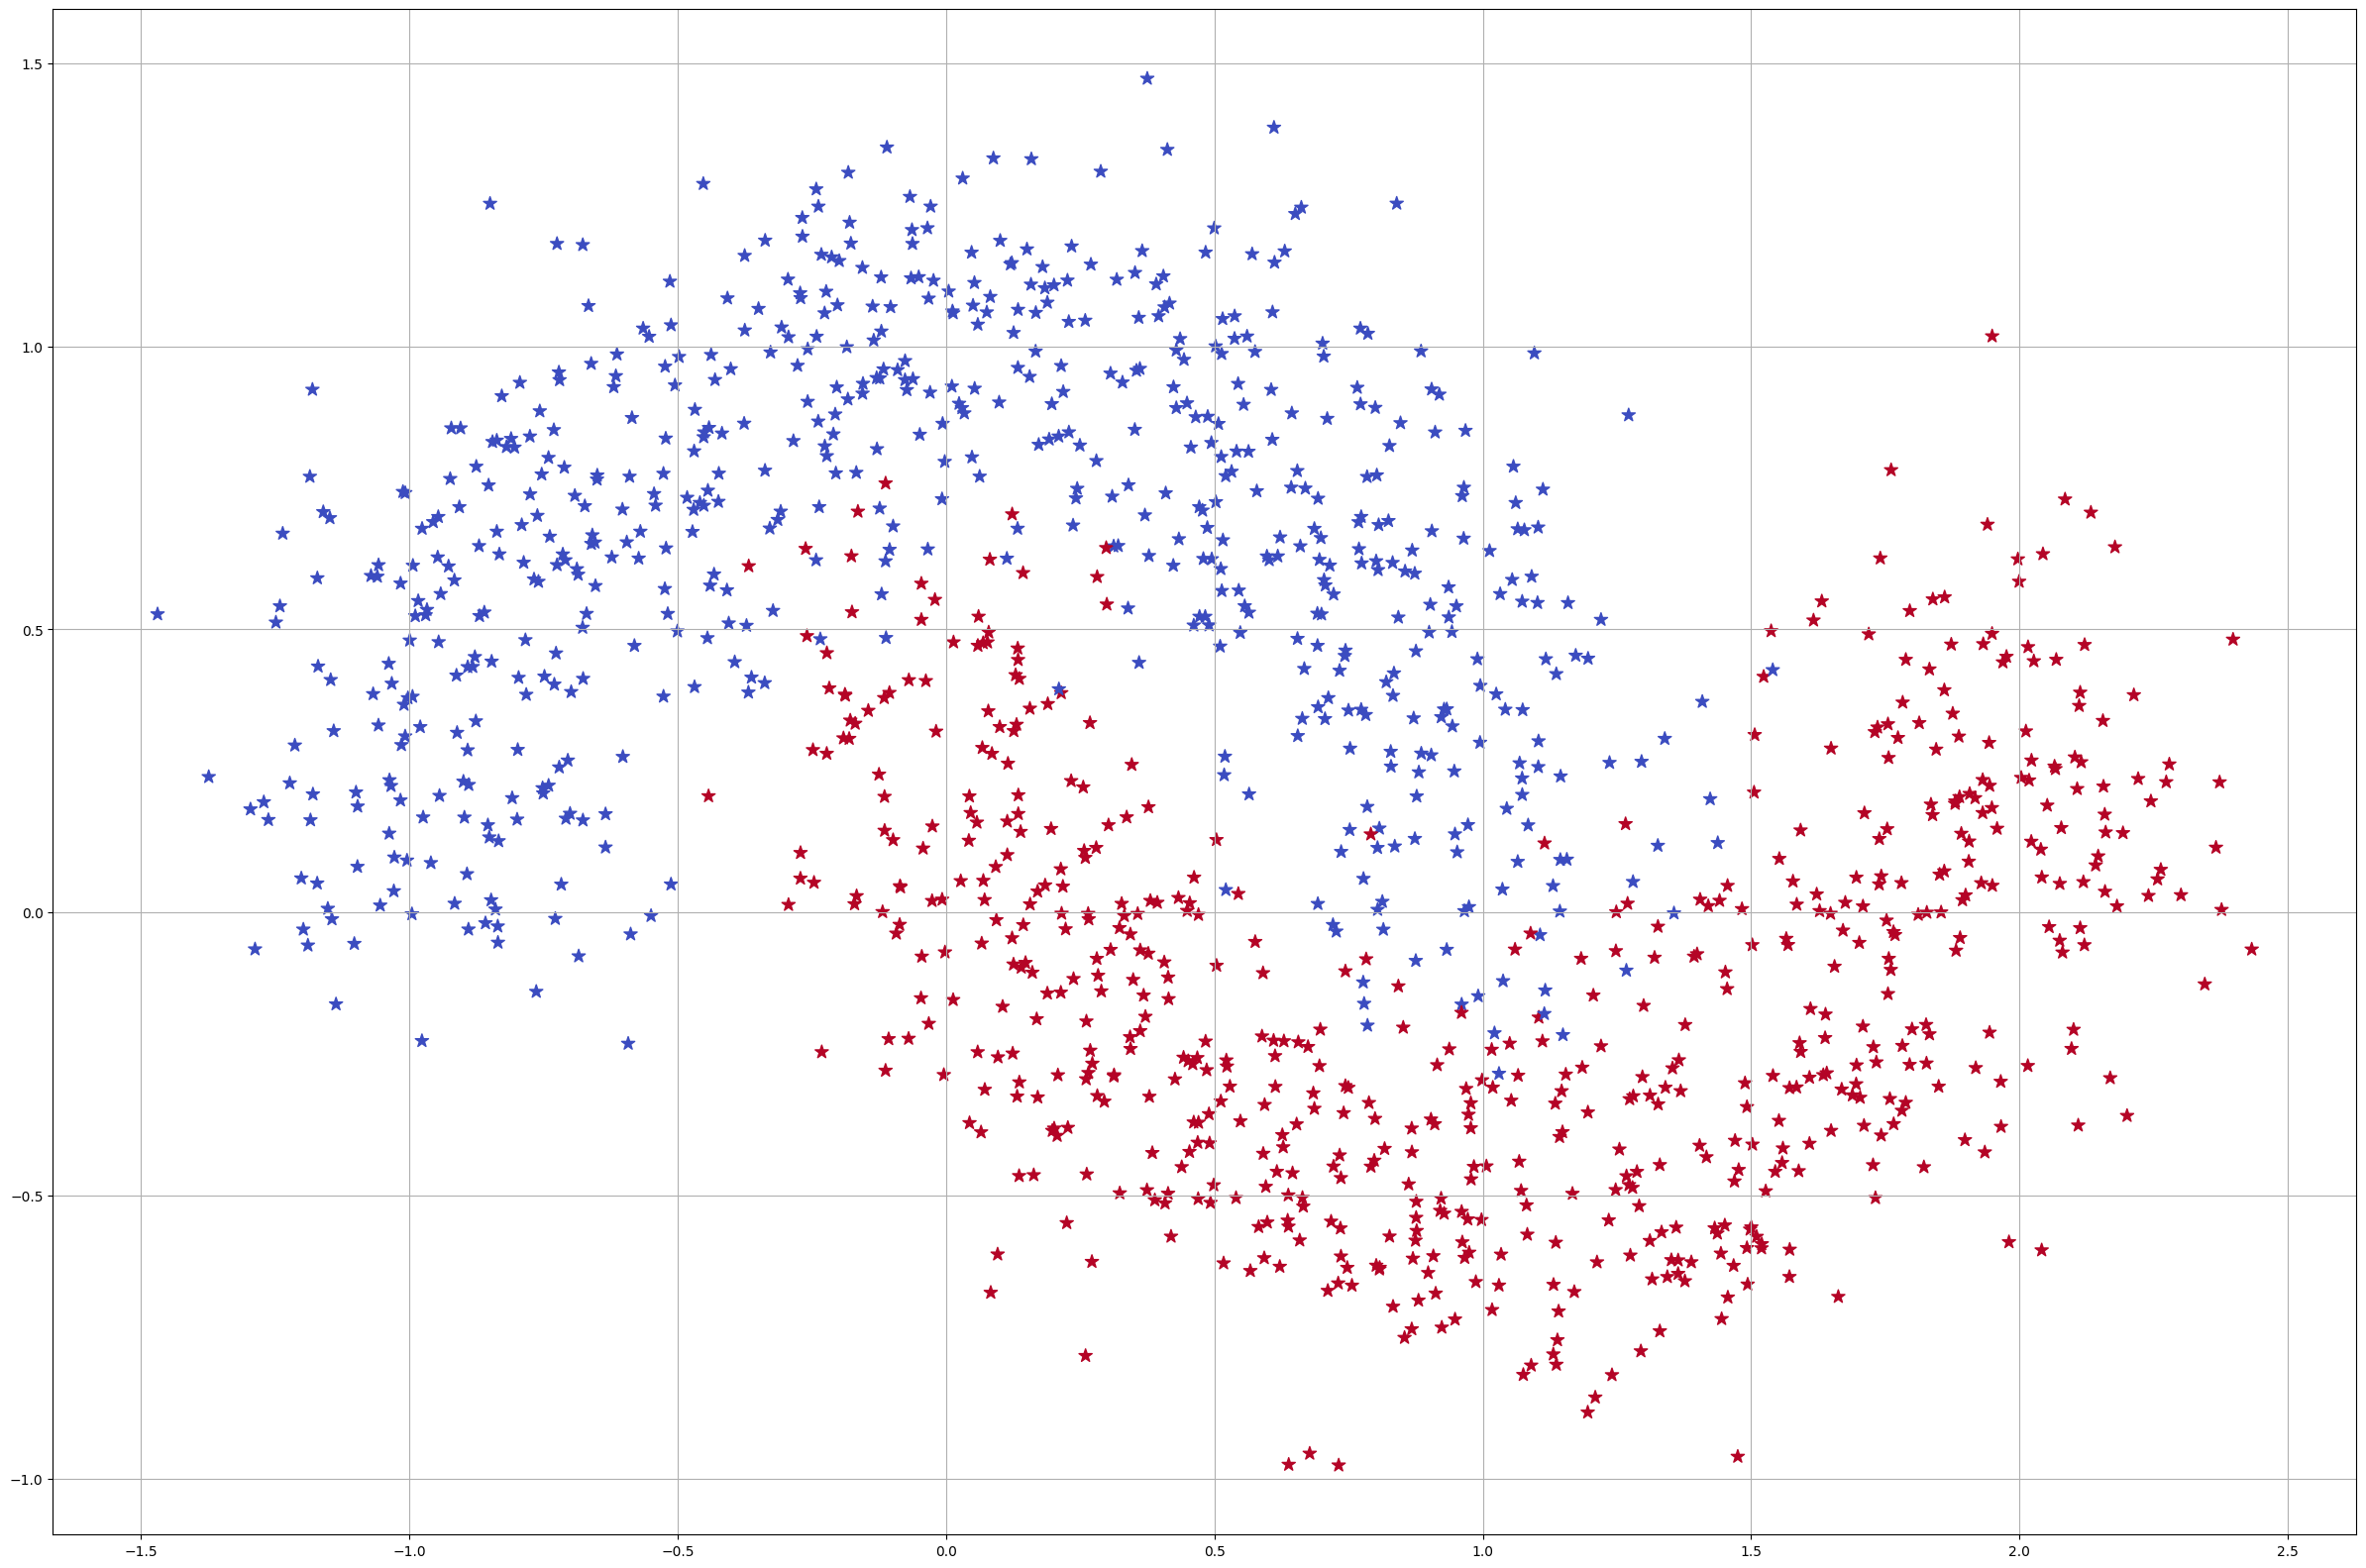

In [8]:
# Lets Plot the data
plt.scatter(X[:,0], X[:,1], s=100, c=y, marker='*', cmap=CMAP)

plt.grid()

In [9]:
y = pd.get_dummies(y).to_numpy()
y

array([[False,  True],
       [ True, False],
       [False,  True],
       ...,
       [ True, False],
       [False,  True],
       [ True, False]], shape=(1280, 2))

In [10]:
#  Split the data in training and test sets to measure performance of the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE,
                                                    random_state=RANDOM_STATE )

print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1024, 2) (1024, 2) (256, 2) (256, 2)


In [11]:
# if you really want to save on space, convert to float32

X_train = X_train.astype(np.float32)

X_test = X_test.astype(np.float32)

y_train = y_train.astype(np.float32)

y_test = y_test.astype(np.float32)

In [12]:
def fn_softmax(z : np.ndarray) -> np.ndarray:
    '''
        Args:
           z : array, Aggregated values 
       Return:
           probs. of each class
    '''
    
    exp_sc = np.exp(z)
    
    return exp_sc / np.sum( exp_sc, axis = 1, keepdims= True)    

In [13]:
sm = fn_softmax(np.asarray([[8, 5, 0], [-10, 0., 10]]))

print (sm, '\n\nTotal of all values', sm.sum(axis = 1))

[[9.52269826e-01 4.74107229e-02 3.19450938e-04]
 [2.06106005e-09 4.53978686e-05 9.99954600e-01]] 

Total of all values [1. 1.]


### Tanh Activation Function

In [14]:
def fn_tanh(z: np.ndarray) -> np.ndarray:
    
    '''
        Args:
           z : array, Aggregated values 
       Return:
           Activations for each z
    '''

    return np.tanh(z)

def fn_tanh_prime(z: np.ndarray) -> np.ndarray:
    '''
        Args:
           z : array, Aggregated values 
       Return:
           Derivative, for each a
    '''

    return 1.0 - np.tanh(z)**2

In [15]:
th = fn_tanh(np.asarray([[-1, 0., 1.], [-np.inf, 0., np.inf]]))
print (th)

[[-0.76159416  0.          0.76159416]
 [-1.          0.          1.        ]]


### Is ourActivation Function working?

In [16]:
np.tanh(0.5)

np.float64(0.46211715726000974)

In [17]:
(1 - np.power(np.tanh(0.5), 2))

np.float64(0.7864477329659274)

In [18]:
fn_tanh_prime(0.5)

np.float64(0.7864477329659274)

## Predict Function

For predictions, we will simply be using the forward propagation. No need to iterate or calculate the back propagation for supervised learning.


In [19]:
# Helper function to predict an output (0 or 1)

def predict(model : dict, X: np.ndarray) -> Literal:
    '''
     Args:
         model
         X: input features
    Returns:
        Predictions against the instances
         
    '''
    W1, b1, W2, b2 = model['W1'],model['b1'],model['W2'],model['b2']
    
    #### Forward Propogation   
    # Layer 1
    z1 = X.dot(W1) + b1 # Agg
    a1 = fn_tanh (z1) # Activation

    # Layer 2
    z2 = a1.dot(W2) + b2
    a2 = fn_softmax(z2)
    
    #return a2>=0.5 # Is it greater than 0.5?
    return np.argmax(a2, axis =1)

In [20]:
# function to evaluate the total loss on the dataset

def calculate_loss(model : dict, X: np.ndarray, y: np.ndarray) -> np.float64:
    '''
    Args:
        model: dictionay object containing weights and biases
        X: Feature Matrix
        y: Labels array
    Returns:
        Average loss
    '''
    W1, b1, W2, b2 = model['W1'],model['b1'],model['W2'],model['b2']
    m = X.shape[0]
    #### Forward Propogation   
    # Layer 1
    z1 = X.dot(W1) + b1 # Agg
    a1 = fn_tanh (z1) # Activation

    # Layer 2
    z2 = a1.dot(W2) + b2
    a2 = fn_softmax(z2)
    
    data_loss = -(y* np.log(a2) + (1-y) * np.log(1-a2)).sum()

    return 1./m * data_loss

## Model

In [21]:
# prepare the Model

def build_model(nn_hdim : np.int64, 
                X_tr : np.ndarray, 
                y_tr : np.ndarray, 
                X_ts : np.ndarray, 
                y_ts : np.ndarray, 
                epochs: np.int64 = EPOCHS, 
                alpha: np.float64 = ALPHA) -> dict:
    
    '''
    Args:
        nn_hdim : Number of nodes in the hidden layer
        X : np.ndarray; Training features to train
        y : np.ndarray; Trainig targets (labels)
        epochs : Number of passes through the training data for gradient descent
        alpha : learning rate
        
    Returns:
        Model: Dictionary object containing weights and biases
    '''
    
    # Initialize the parameters to random values. We need to learn these.
    # Weights
    
    '''
    ##### 
            Change from Rand to Randn gives different shape fo the loss curve
            Demonstrate in the class
    #####
    '''
    m = X_tr.shape[0]
    W1 = np.random.rand(nn_input_dim, nn_hdim) / np.sqrt(nn_input_dim)
    W2 = np.random.rand(nn_hdim, nn_output_dim) / np.sqrt(nn_hdim)
    
    b1 = np.zeros ((1, nn_hdim))
    b2 = np.zeros ((1, nn_output_dim))
    
    curr_loss = 0
    
    loss = []
    epoch = []
    #################
    # For Animation #
    #################
    interval = INTERVAL # interval to create animation images
    plot_epoch = np.arange(0, epochs, interval) # x axis for plotting loss
    plot_loss_df = pd.DataFrame(plot_epoch, columns= ['epoch'])
    plot_loss_df['loss'] = None
    plot_idx = 0
    
    # W1 is (2,4) -> 8 elements, W2 is (4,2) -> 8 elements
    for i in range(W1.shape[0] * W1.shape[1]):
        plot_loss_df[f'W1_{i}'] = None
    for i in range(W2.shape[0] * W2.shape[1]):
        plot_loss_df[f'W2_{i}'] = None
    for i in range (0, epochs):
        
        #### Forward Propagation
        
        # Layer 1
        z1 = X_tr.dot(W1) + b1 # Agg
        a1 = fn_tanh (z1) # Activation
        
        # Layer 2
        z2 = a1.dot(W2) + b2
        a2 = fn_softmax(z2)
        
        ### Back Propagation
        
        dz2 = a2 - y_tr
        
        dW2 = (a1.T).dot(dz2)
        assert (W2.shape == dW2.shape), 'Shape of W2 {} and shape of dW2 {}'.format(W2.shape, dW2.shape)
        db2 = np.sum(dz2, axis = 0, keepdims=True)
        
        dz1 = dz2.dot(W2.T) * fn_tanh_prime(z1)
        
        dW1 = (X_tr.T).dot(dz1)
        assert (W1.shape == dW1.shape), 'Shape of W1 {} and shape of dW1 {}'.format(W1.shape, dW1.shape)
        db1 = np.sum(dz1, axis = 0, keepdims=True)
        
        ########################
        ### Gradient Updates ###
        ########################
        # gradients are being updated for every epoch
        W1 += -alpha *dW1 / m
        W2 += -alpha *dW2 / m
        b1 += -alpha *db1 / m
        b2 += -alpha *db2 / m
        
        # Store model in a dict object
        model = {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}
        
        # for every nth epoch calculate loss for future plotting
        if i%interval ==  0: 
            curr_loss = calculate_loss (model, X, y)
            loss.append(curr_loss)
            epoch.append(i)
            plot_loss_df.loc[plot_idx, 'loss'] = curr_loss

            # Flatten and store W1 weights (2,4 matrix -> 8 elements)
            w1_flat = W1.flatten()
            for j, weight_val in enumerate(w1_flat):
                plot_loss_df.loc[plot_idx, f'W1_{j}'] = weight_val
                
            # Flatten and store W2 weights (4,2 matrix -> 8 elements)  
            w2_flat = W2.flatten()
            for j, weight_val in enumerate(w2_flat):
                plot_loss_df.loc[plot_idx, f'W2_{j}'] = weight_val
            #display(plot_loss_df)
            fn_save_decision_boundary(lambda x: predict(model, x), 
                                      X_tr, y_tr, X_ts, y_ts,
                                      plot_idx,
                                      plot_loss_df) # save decision boundary for animation
            plot_idx +=1
            # if plot_idx> 5:
            #     break
                
        # print loss every nth epoch    
        if i%1000 == 0:
            print(f'loss after {i} epoch : {curr_loss}') 
    # update loss_hist
    loss_hist['epoch'] =epoch
    loss_hist['loss'] = loss
    
    display(plot_loss_df)
    return model

In [22]:
num_examples, nn_input_dim = X_train.shape # training set size (rows and cols)
nn_output_dim = y_train.shape[1] # output layer dimensionality

# lists to facilitate plotting 
loss_hist = {}

artists = []

loss after 0 epoch : 1.358613890027804


KeyboardInterrupt: 

<Figure size 3000x2000 with 0 Axes>

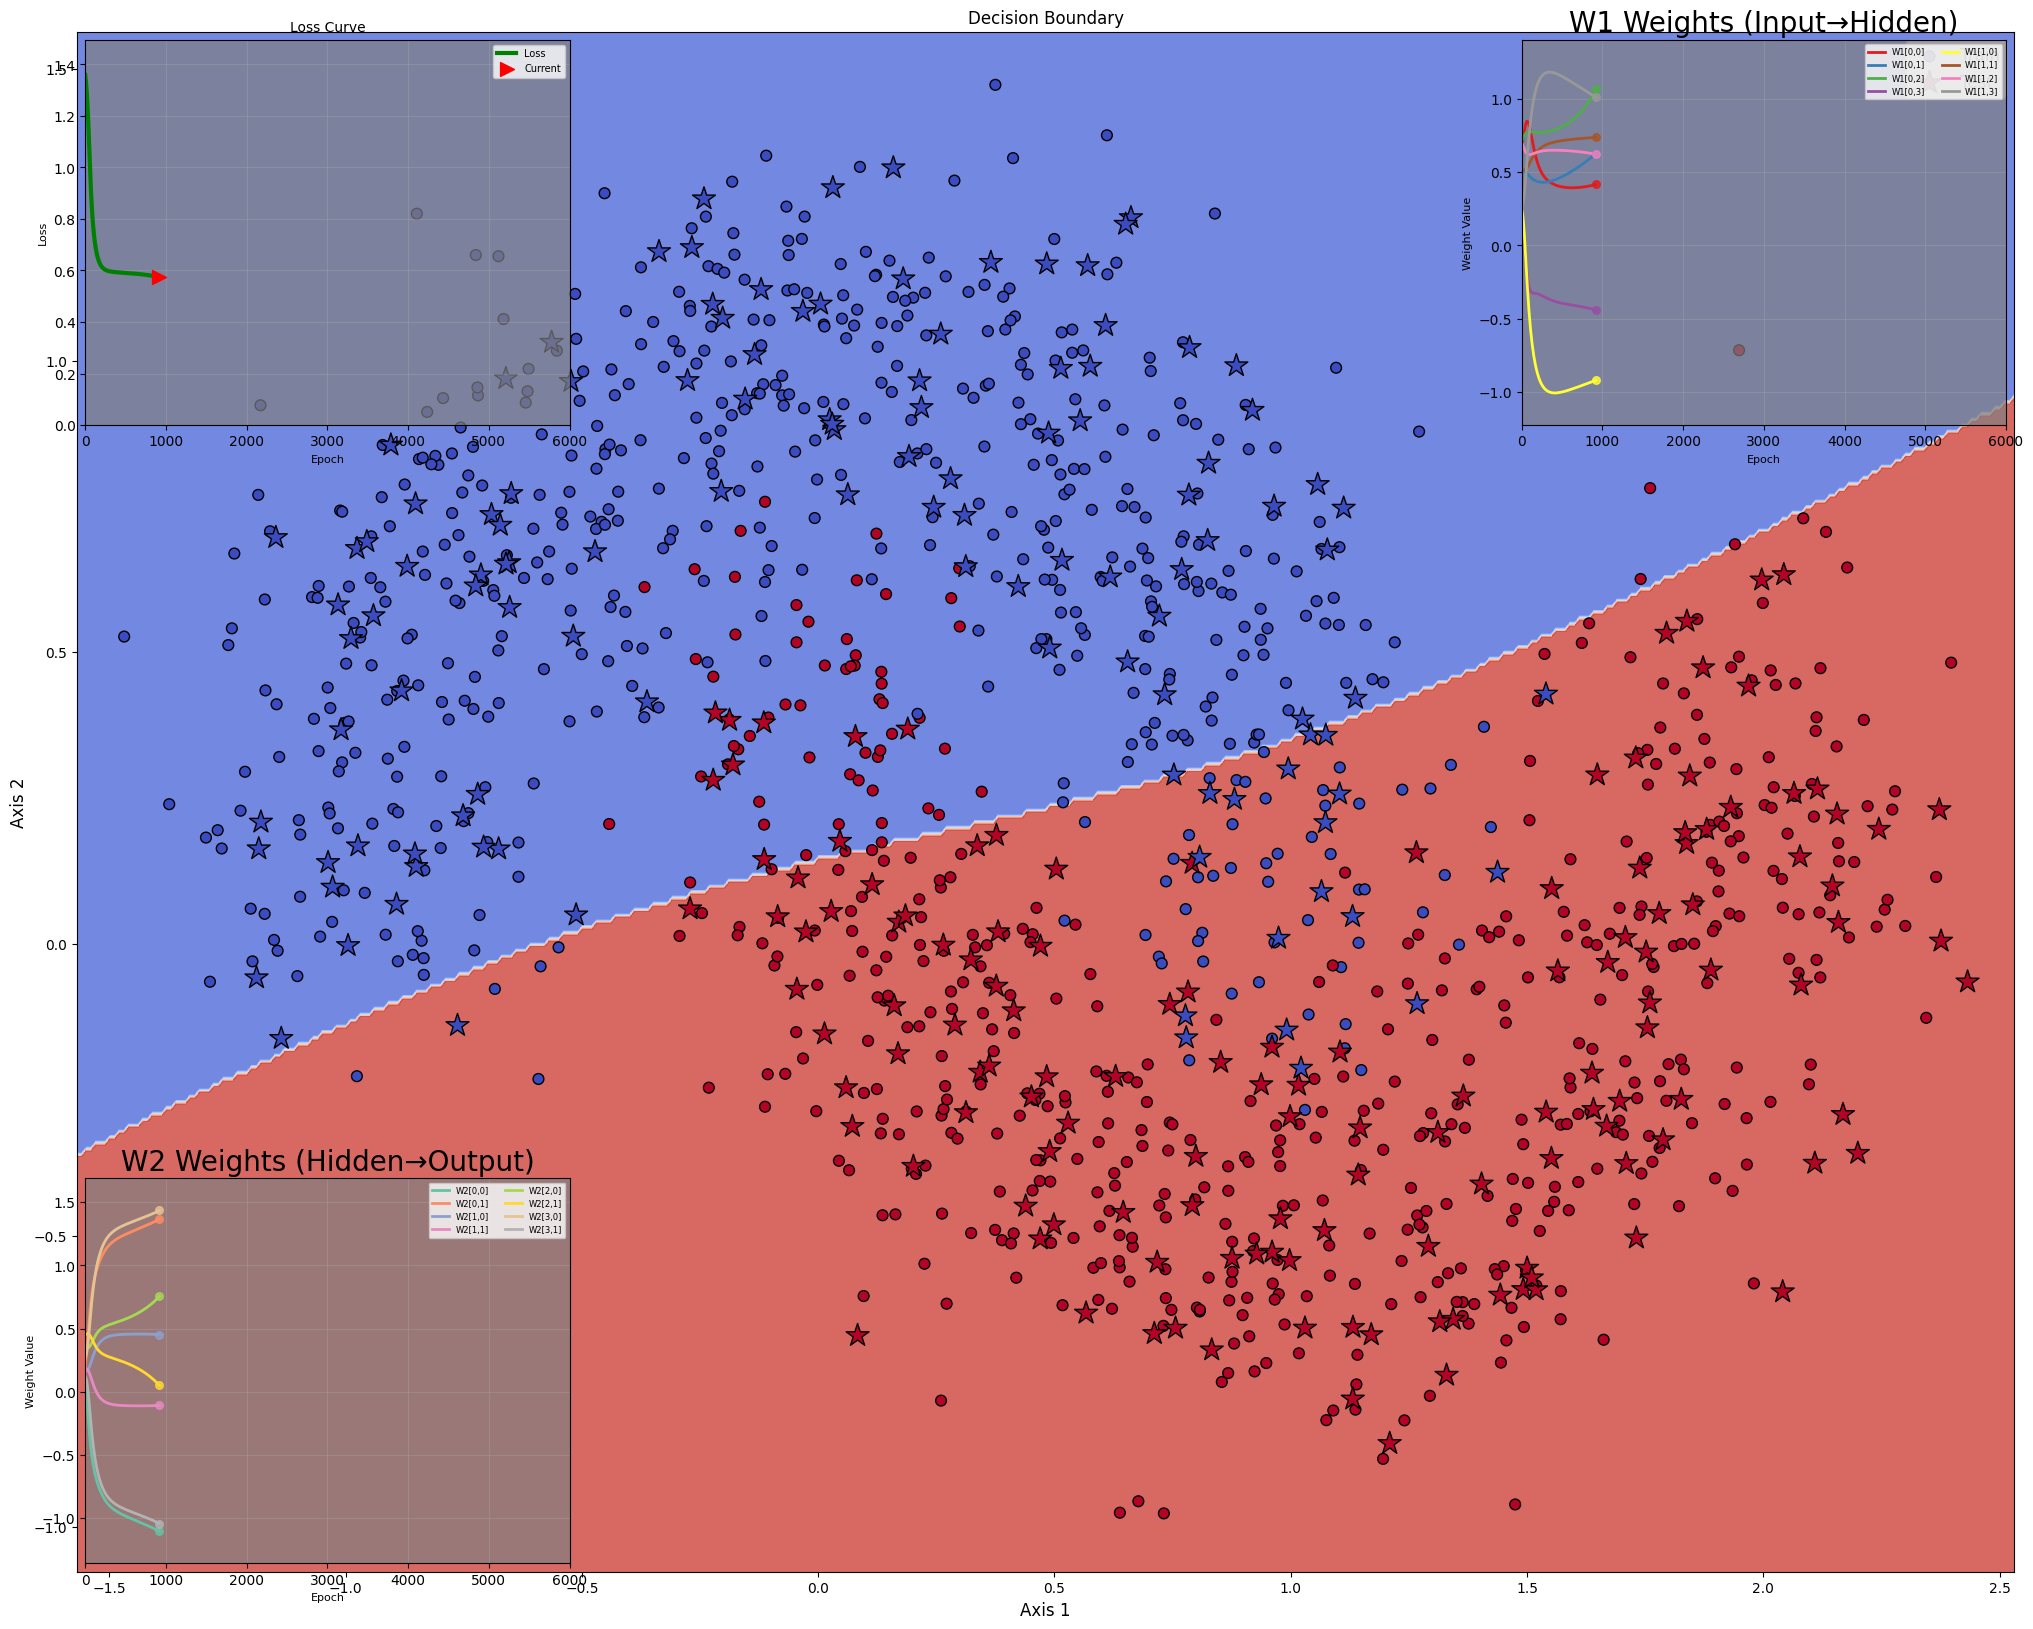

In [24]:
# Build a model with a 4-dimensional hidden layer
model = build_model(4, X_train, y_train,X_test, y_test,
                    epochs = EPOCHS, 
                    alpha = ALPHA)